---
format:
    html: default
    ipynb: default
jupyter: python3
---


## Explaining CNNs


In this assignment you implement two explainer algorithms for Convolutional Neural Networks (CNNs) and use them to inspect a model you have already trained. An explainer answers a question that accuracy alone cannot: which parts of an input drove this particular prediction? For an image classifier that answer takes the form of a saliency map, and a trustworthy map should highlight the animal rather than the background, a watermark, or some dataset artifact the model latched onto.

We invite you to watch the following video, which sets the context and walks through the tools you can use. Click the thumbnail to open it on YouTube.

[![Watch the assignment introduction on YouTube](https://img.youtube.com/vi/Am2EF9CLu-g/hqdefault.jpg)](https://www.youtube.com/watch?v=Am2EF9CLu-g)

In the [cats vs dogs](https://huggingface.co/datasets/pantelism/cats-vs-dogs) [classification task](https://aegean.ai/aiml-common/lectures/cnn/cnn-example-architectures/using_convnets_with_small_datasets) you trained a model that, with the help of data augmentation, reached a useful level of accuracy without overfitting. That trained model is your subject here. You do not retrain it or change its architecture; you attach explainers to it and interpret what they reveal about how it decides.

### The two methods you will implement

**Integrated gradients** ([Sundararajan et al., 2017](https://arxiv.org/abs/1703.01365)) attributes a prediction to individual input pixels. It picks a baseline image (commonly an all-black image, which the model should find uninformative) and integrates the gradient of the class score along the straight-line path from that baseline to the actual input. The result is a per-pixel attribution with two properties that plain input gradients lack: completeness, meaning the attributions sum to the difference in model output between the input and the baseline, and robustness to saturated activations, where a plain gradient would read close to zero even though the feature mattered.

**Grad-CAM** ([Selvaraju et al., 2016](https://arxiv.org/abs/1610.02391)) produces a coarse, class-discriminative heatmap. It takes the feature maps of a convolutional layer, usually the last one, and weights each map by the gradient of the class score flowing into it. Because it works at the resolution of a deep feature map rather than the raw pixels, it localizes the region the network used instead of scoring every pixel.

The two methods sit at opposite ends of a resolution trade-off: integrated gradients is fine-grained and pixel-level, Grad-CAM is coarse and region-level. Running both on the same image and noting where they agree, and where they do not, is the heart of this assignment.

We strongly advise PyTorch with [Captum](https://captum.ai/tutorials/) unless you already have Keras/TF expertise, because both methods ship as ready implementations there (`IntegratedGradients` and `LayerGradCam`). You are free to use the high-level APIs of the framework of your choice.

### What to submit

For each method, in the cells below:

- A markdown explanation written so that anyone who understands how a CNN works can follow it. Cover the intuition, the role of the baseline (integrated gradients) or the target layer (Grad-CAM), and one limitation of the method.
- Working code that runs the explainer on at least three correctly classified images and at least one image the model got wrong.
- The resulting maps overlaid on the input images, each with a one-line caption stating what the map suggests the model attended to.

### How your work is evaluated

- Correctness: the right baseline, the right target layer, and gradients taken with respect to the predicted class rather than a fixed label.
- Visualization quality: maps are overlaid on the inputs, readable, and labeled.
- Depth of interpretation: noting that a map "looks reasonable" is not enough. Point to where the two methods agree, where they disagree, and what the misclassified example tells you about what the model actually learned.

# CNN Explainers: Integrated Gradients and Grad-CAM

**Name:** Jacob Moawad

In this notebook I load my cats and dogs model and use two methods to see what parts of the images the model used. I use three images that the model got right and one image that it got wrong.


## 1. Setup

The model file `cats_and_dogs_small.pth` has to be in the same folder as this notebook.


In [9]:
%pip install -q captum datasets


Note: you may need to restart the kernel to use updated packages.


In [10]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from datasets import load_dataset
from captum.attr import IntegratedGradients, LayerGradCam, LayerAttribution

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Device:", device)


Device: mps


## 2. Load the data and model

The labels are 0 for cat and 1 for dog. I use the same image size and normalization that I used when the model was trained.


In [11]:
data = load_dataset("pantelism/cats-vs-dogs")
names = data["test"].features["label"].names

tf = transforms.Compose([
    transforms.Resize((150, 150)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

class MyData(Dataset):
    def __init__(self, data, tf):
        self.data = data
        self.tf = tf

    def __len__(self):
        return len(self.data)

    def __getitem__(self, i):
        row = self.data[i]
        img = row["image"].convert("RGB")
        y = int(row["label"])
        return self.tf(img), y, i

test_data = MyData(data["test"], tf)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False, num_workers=0)

print("Test images:", len(test_data))
print("Labels:", names)


Test images: 1000
Labels: ['cat', 'dog']


In [12]:
class SmallConvNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(128, 128, 3),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(128 * 7 * 7, 512),
            nn.ReLU(),
            nn.Linear(512, 1)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x).squeeze(1)

file = Path("cats_and_dogs_small.pth")

if not file.exists():
    raise FileNotFoundError("Put cats_and_dogs_small.pth in the same folder as this notebook")

net = SmallConvNet().to(device)
net.load_state_dict(torch.load(file, map_location=device, weights_only=True))
net.eval()

print("Model loaded")


Model loaded


## 3. Pick the images

I run the model on the test set. Then I pick the first three correct answers and the first wrong answer.


In [13]:
probs = []
labels = []

with torch.no_grad():
    for x, y, i in test_loader:
        out = net(x.to(device))
        p = torch.sigmoid(out).cpu().numpy()
        probs.extend(p)
        labels.extend(y.numpy())

probs = np.array(probs)
labels = np.array(labels)
preds = (probs >= 0.5).astype(int)

right = np.where(preds == labels)[0]
wrong = np.where(preds != labels)[0]

if len(right) < 3 or len(wrong) < 1:
    raise RuntimeError("There are not enough correct or wrong examples")

use = [int(right[0]), int(right[1]), int(right[2]), int(wrong[0])]

print("Test accuracy:", (preds == labels).mean())
print("Images used:", use)

for i in use:
    print(i, "true:", names[labels[i]], "predicted:", names[preds[i]])


Test accuracy: 0.705
Images used: [0, 2, 3, 1]
0 true: cat predicted: cat
2 true: cat predicted: cat
3 true: cat predicted: cat
1 true: cat predicted: dog


# Integrated Gradients

Integrated Gradients starts with a baseline image and slowly changes it into the real image. It checks the gradient many times during this change. The result shows which pixels had more effect on the prediction.

I use a black image for the baseline. The images were normalized, so black is stored as -1 instead of 0.

One problem with this method is that the answer can change if a different baseline is used. The map can also look noisy.


# Grad-CAM

Grad-CAM uses the feature maps from a convolution layer. It uses the gradients to find which feature maps mattered most and makes a heatmap from them.

I use `net.features[9]` because it is the last convolution layer. It still has location information and it contains features learned near the end of the network.

One problem with Grad-CAM is that the map is not very detailed because the feature map is much smaller than the original image.


## 4. Make the explanations

For a dog prediction I explain the model output. For a cat prediction I explain the negative model output. This makes the explanation use the class that the model predicted.


In [14]:
class Score(nn.Module):
    def __init__(self, net, pred):
        super().__init__()
        self.net = net
        self.pred = pred

    def forward(self, x):
        out = self.net(x)
        if self.pred == 1:
            return out.unsqueeze(1)
        return (-out).unsqueeze(1)

def fix_map(a):
    a = a - a.min()
    if a.max() > 0:
        a = a / a.max()
    return a

def to_img(x):
    img = x.detach().cpu().squeeze(0)
    img = img * 0.5 + 0.5
    img = img.clamp(0, 1)
    return img.permute(1, 2, 0).numpy()

def add_map(img, h):
    c = plt.get_cmap("jet")(h)[..., :3]
    return np.clip(img * 0.55 + c * 0.45, 0, 1)

def where(h):
    y, x = np.unravel_index(np.argmax(h), h.shape)

    if y < h.shape[0] / 3:
        a = "top"
    elif y < h.shape[0] * 2 / 3:
        a = "middle"
    else:
        a = "bottom"

    if x < h.shape[1] / 3:
        b = "left"
    elif x < h.shape[1] * 2 / 3:
        b = "center"
    else:
        b = "right"

    return a + " " + b

def explain(i):
    row = data["test"][i]
    img = row["image"].convert("RGB")
    true = int(row["label"])
    x = tf(img).unsqueeze(0).to(device)

    with torch.no_grad():
        p = torch.sigmoid(net(x))[0].item()

    pred = int(p >= 0.5)
    score = Score(net, pred).to(device)

    base = torch.full_like(x, -1.0)
    ig = IntegratedGradients(score)
    a = ig.attribute(x, baselines=base, target=0, n_steps=32)
    ig_map = a[0].abs().sum(dim=0).detach().cpu().numpy()
    ig_map = fix_map(ig_map)

    cam = LayerGradCam(score, net.features[9])
    b = cam.attribute(x, target=0)
    b = LayerAttribution.interpolate(b, (150, 150))
    cam_map = torch.relu(b[0, 0]).detach().cpu().numpy()
    cam_map = fix_map(cam_map)

    real_img = to_img(x)

    return {
        "i": i,
        "img": real_img,
        "true": true,
        "pred": pred,
        "p": p,
        "ig": ig_map,
        "cam": cam_map,
        "ig_img": add_map(real_img, ig_map),
        "cam_img": add_map(real_img, cam_map)
    }


## 5. Show the results

The brighter colors show the parts that had more importance for the prediction.


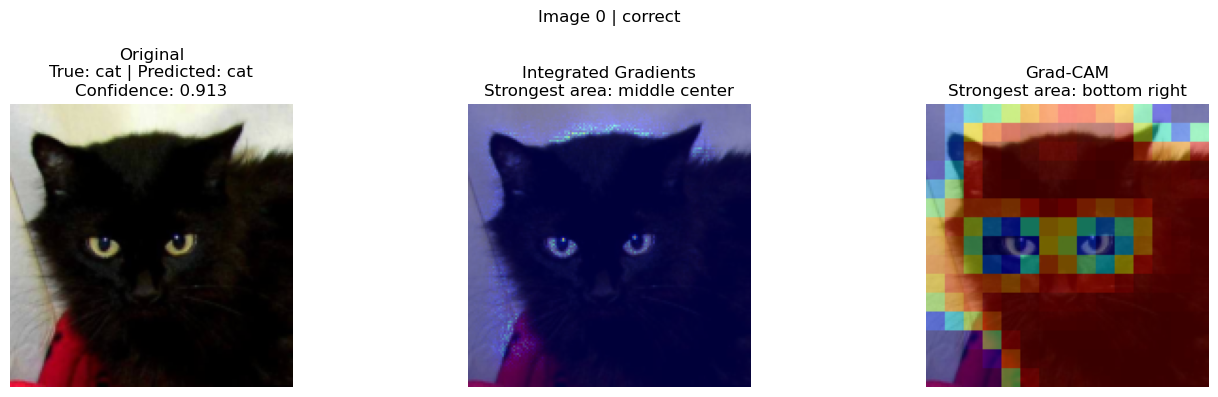

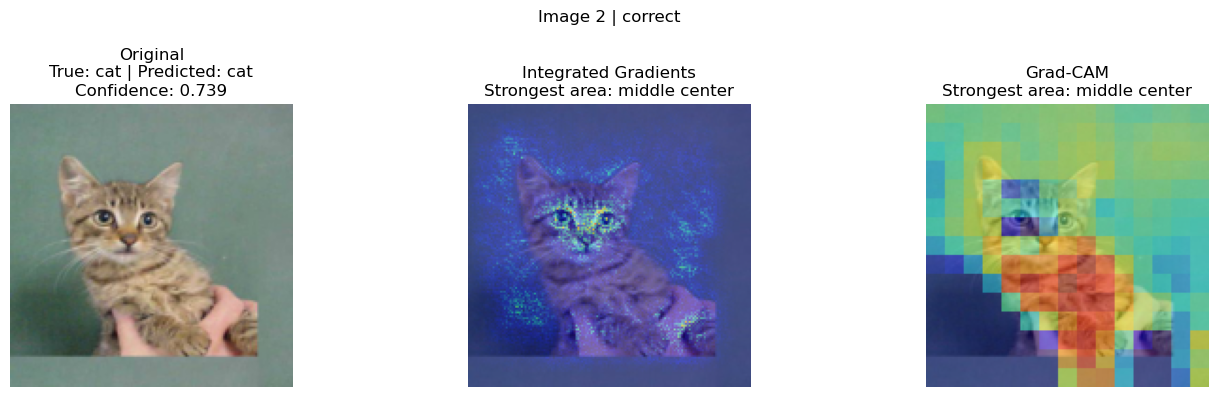

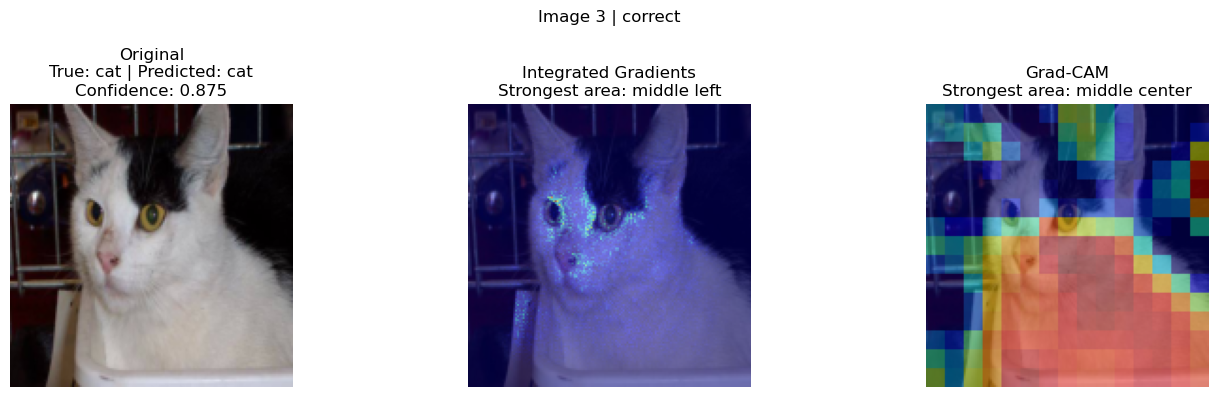

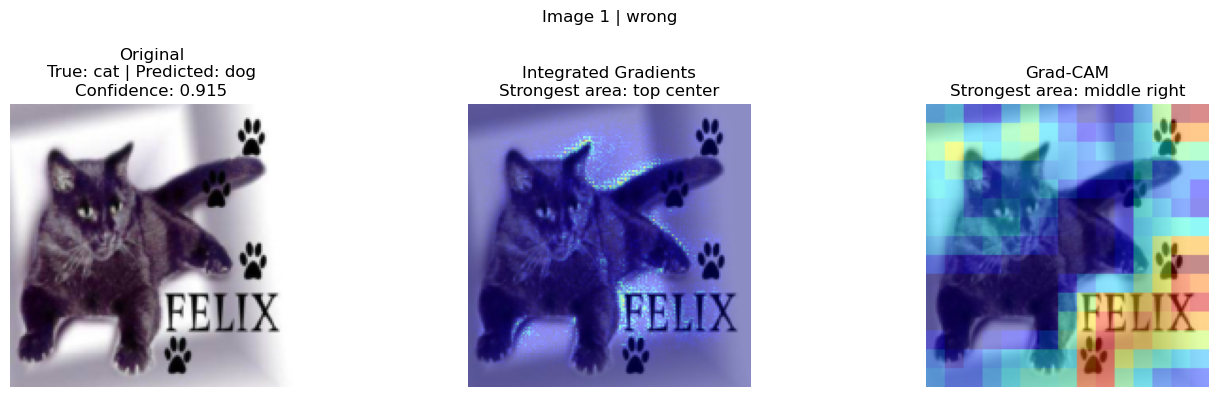

In [15]:
ans = []

for i in use:
    r = explain(i)
    ans.append(r)

    if r["pred"] == 1:
        conf = r["p"]
    else:
        conf = 1 - r["p"]

    if r["true"] == r["pred"]:
        result = "correct"
    else:
        result = "wrong"

    fig, ax = plt.subplots(1, 3, figsize=(14, 4))

    ax[0].imshow(r["img"])
    ax[0].set_title(
        "Original\nTrue: " + names[r["true"]] +
        " | Predicted: " + names[r["pred"]] +
        "\nConfidence: " + str(round(conf, 3))
    )

    ax[1].imshow(r["ig_img"])
    ax[1].set_title("Integrated Gradients\nStrongest area: " + where(r["ig"]))

    ax[2].imshow(r["cam_img"])
    ax[2].set_title("Grad-CAM\nStrongest area: " + where(r["cam"]))

    for a in ax:
        a.axis("off")

    plt.suptitle("Image " + str(i) + " | " + result)
    plt.tight_layout()
    plt.show()


## 6. Compare the methods

Integrated Gradients gives a more detailed map because it works with the input pixels. Grad-CAM gives a bigger and smoother area because it uses the last convolution layer.

The code below compares the general area picked by both methods. If they show the same area, they agree. If they show different areas, they disagree.


In [16]:
for n, r in enumerate(ans, start=1):
    a = where(r["ig"])
    b = where(r["cam"])

    if a == b:
        text = "Both methods focused on the same general area."
    else:
        text = "The methods focused on different areas."

    if r["true"] == r["pred"]:
        result = "correct"
    else:
        result = "wrong"

    print("Example", n, "(" + result + ")")
    print("Integrated Gradients:", a)
    print("Grad-CAM:", b)
    print(text)
    print()

print("The wrong example shows that the model can look at part of the image and still make a mistake.")
print("It may confuse similar animal features or use something from the background.")


Example 1 (correct)
Integrated Gradients: middle center
Grad-CAM: bottom right
The methods focused on different areas.

Example 2 (correct)
Integrated Gradients: middle center
Grad-CAM: middle center
Both methods focused on the same general area.

Example 3 (correct)
Integrated Gradients: middle left
Grad-CAM: middle center
The methods focused on different areas.

Example 4 (wrong)
Integrated Gradients: top center
Grad-CAM: middle right
The methods focused on different areas.

The wrong example shows that the model can look at part of the image and still make a mistake.
It may confuse similar animal features or use something from the background.


## Conclusion

Integrated Gradients showed smaller pixel details, while Grad-CAM showed a larger area. When both methods focused on the same place, it gave more support that the area mattered to the prediction. The wrong example showed that the model did not always learn the correct visual clue.
